A DataFrame is a two-dimensional table (rows + columns).

Key operations:

Selecting columns and rows (loc, iloc)

Adding or deleting columns

Renaming columns

Sorting and ranking

Handling missing data (dropna, fillna)

Type conversion (astype)

Why this matters:
Most real-world datasets (CSV, Excel, SQL tables) are naturally represented as DataFrames.

The two most powerful libraries in the Python data ecosystem
ready to build a high-performance preprocessing pipeline.

use NumPy for heavy mathematical operations and Pandas for structured data manipulation.


In [4]:
import pandas as pd
import numpy as np

# Creating from a dictionary (Keys become columns)
data = {
    'Product': ['Laptop', 'Tablet', 'Phone'],
    'Price': [1200, 450, 800],
    'In_Stock': [True, False, True]
}

df = pd.DataFrame(data)
df

,Product,Price,In_Stock
0,Laptop,1200,True
1,Tablet,450,False
2,Phone,800,True


### Data.org Financial Health Prediction Challenge!
##### You'll be working with real-world data from Zimbabwe, Malawi, Eswatini, and Lesotho, featuring:

Business characteristics (age, expenses, income)
Owner demographics (age, attitudes, perceptions)
Financial behavior (banking access, insurance, savings patterns)
Risk factors (concerns about theft, business stability)

In [5]:
# Data load
train_df = pd.read_csv('Train.csv')
train_df

,ID,country,owner_age,attitude_stable_business_environment,attitude_worried_shutdown,compliance_income_tax,perception_insurance_doesnt_cover_losses,perception_cannot_afford_insurance,personal_income,business_expenses,...,has_internet_banking,has_debit_card,future_risk_theft_stock,business_age_months,medical_insurance,funeral_insurance,motivation_make_more_money,uses_friends_family_savings,uses_informal_lender,Target
0,ID_3CFL0U,eswatini,63.0,Yes,No,No,No,Yes,3000.0,6000.0,...,Never had,Never had,NaN,6.0,Never had,Used to have but don’t have now,NaN,Never had,Never had,Low
1,ID_XWI7G3,zimbabwe,39.0,No,Yes,Yes,No,Yes,NaN,NaN,...,NaN,NaN,No,3.0,Never had,Never had,NaN,NaN,NaN,Medium
2,ID_TY93LV,malawi,34.0,Don’t know or N/A,No,No,Don't know,Yes,30000.0,6000.0,...,Never had,Never had,Yes,NaN,NaN,NaN,Yes,NaN,NaN,Low
3,ID_9OP2C8,malawi,28.0,Yes,No,No,No,No,180000.0,60000.0,...,Never had,Never had,No,NaN,NaN,NaN,Yes,Never had,Have now,Low
4,ID_13REYS,zimbabwe,43.0,Yes,No,No,Yes,Yes,50.0,2400.0,...,NaN,NaN,No,0.0,Never had,Never had,Yes,NaN,NaN,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9613,ID_D7NC2D,lesotho,31.0,Yes,No,No,Don't know,Don't know,2000.0,800.0,...,NaN,NaN,NaN,NaN,NaN,NaN,No,Have now,Never had,Medium
9614,ID_NT06RL,malawi,64.0,Don’t know or N/A,Don’t know or N/A,Yes,No,No,10000000.0,5000000.0,...,Never had,Have now,Yes,NaN,NaN,NaN,No,NaN,NaN,High
9615,ID_4TVWA3,zimbabwe,43.0,Yes,No,No,Yes,No,450.0,NaN,...,NaN,NaN,No,8.0,Have now,Have now,NaN,NaN,NaN,Medium
9616,ID_3U3S2Z,zimbabwe,38.0,Yes,Yes,No,No,Yes,2000.0,NaN,...,NaN,NaN,No,0.0,Never had,Never had,NaN,NaN,NaN,Low


In [6]:
train_df.describe()

,owner_age,personal_income,business_expenses,business_turnover,business_age_years,business_age_months
count,9618.000000,9.509000e+03,9.389000e+03,9.402000e+03,9366.000000,5507.000000
mean,41.705344,2.627345e+05,4.583838e+05,1.348210e+06,7.030536,3.636281
std,13.314010,2.566268e+06,6.184746e+06,8.804741e+06,7.650349,3.386488
min,18.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000
25%,32.000000,3.000000e+02,7.000000e+02,1.500000e+03,2.000000,0.000000
50%,40.000000,2.000000e+03,3.000000e+03,6.000000e+03,4.000000,3.000000
75%,50.000000,2.500000e+04,2.500000e+04,5.000000e+04,10.000000,6.000000
max,103.000000,1.500000e+08,5.000000e+08,4.200000e+08,60.000000,11.000000


#### Data Cleaning
Cleaning isn't just about deleting rows; it's about making informed decisions on how to treat "noise" without introducing bias.

Core Techniques
Imputation: Filling missing values using statistical measures (mean/median) or predictive modeling (KNN Imputer).

Deduplication: Distinguishing between genuine duplicates and coincidental data points.

Constraint Checking: Ensuring values fall within logical ranges (e.g., age cannot be negative).

In [3]:
print(train_df.isnull().sum())
# Removing Duplicates
train_df = train_df.drop_duplicates(keep='first')
#train_df= train_df.dropna(subset=['ID'], inplace=True)   # Drop rows where ID is missing
# Formatting: Standardizing strings
## train_df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

ID                                                                     0
country                                                                0
owner_age                                                              0
attitude_stable_business_environment                                   2
attitude_worried_shutdown                                              2
compliance_income_tax                                                  4
perception_insurance_doesnt_cover_losses                               5
perception_cannot_afford_insurance                                     5
personal_income                                                      109
business_expenses                                                    229
business_turnover                                                    216
business_age_years                                                   252
motor_vehicle_insurance                                             2244
has_mobile_money                                   

In [10]:
train_df['personal_income'].median()

2000.0

In [4]:
#filling missing data
train_df['compliance_income_tax'] = train_df['compliance_income_tax'].fillna("No") # most SME doesnt pay tax if income less that 300
train_df['motor_vehicle_insurance'] = train_df['motor_vehicle_insurance'].fillna("Never had")
# Fill missing income based on the median of their Country and Insurancw
train_df['personal_income'] = train_df['personal_income'].fillna(
    train_df.groupby(['country', 'has_insurance'])['personal_income'].transform('median') #Income varies wildly by country and education level
) 

These methods look at a single column to determine the replacement value.

Mean Imputation: Best for normally distributed numerical data.

Median Imputation: Preferred if the data has outliers, as the median is more robust.

Mode Imputation: Used for categorical data (e.g., filling "Color" with the most frequent value).

Constant Value: Filling with a specific flag like "Unknown" or 0.

###### time series imputation

Standard mean/median imputation destroys the "flow" of time-series data. Instead, we use:

Forward Fill (ffill): Carries the last known value forward.

Backward Fill (bfill): Uses the next known value.

Linear Interpolation: Draws a straight line between two known points.

Linear interpolation is often the 'gold standard' for time series


df['Temperature'] = df['Temperature'].interpolate(method='linear')

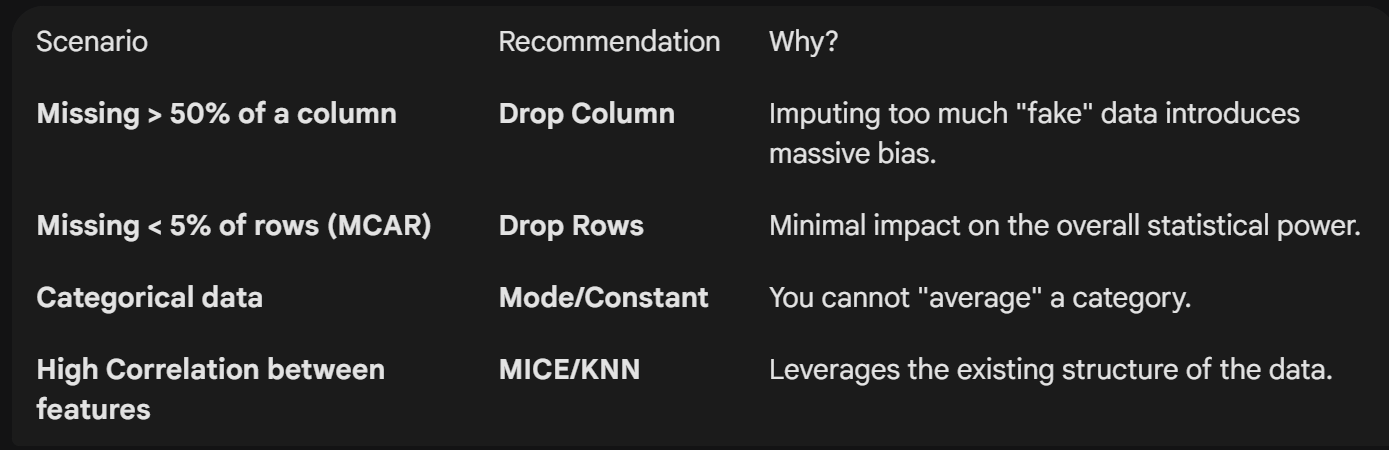

In [5]:
##In your original graph, 95% of people were squashed into one tiny bar. After the log, they are spread across the
## x-axis, allowing the model to see the difference between "Low" and "Middle" income.
# (This handles cases where the data might have been integers or objects)
train_df['personal_income'] = train_df['personal_income'].astype('float64')
train_df['business_expenses'] = train_df['business_expenses'].astype('float64')

# 2. Log transformations (these are float64 by default, but we can be explicit)
train_df['personal_income_log'] = np.log1p(train_df['personal_income']).astype('float64')
train_df['business_expenses_log'] = np.log1p(train_df['business_expenses']).astype('float64')

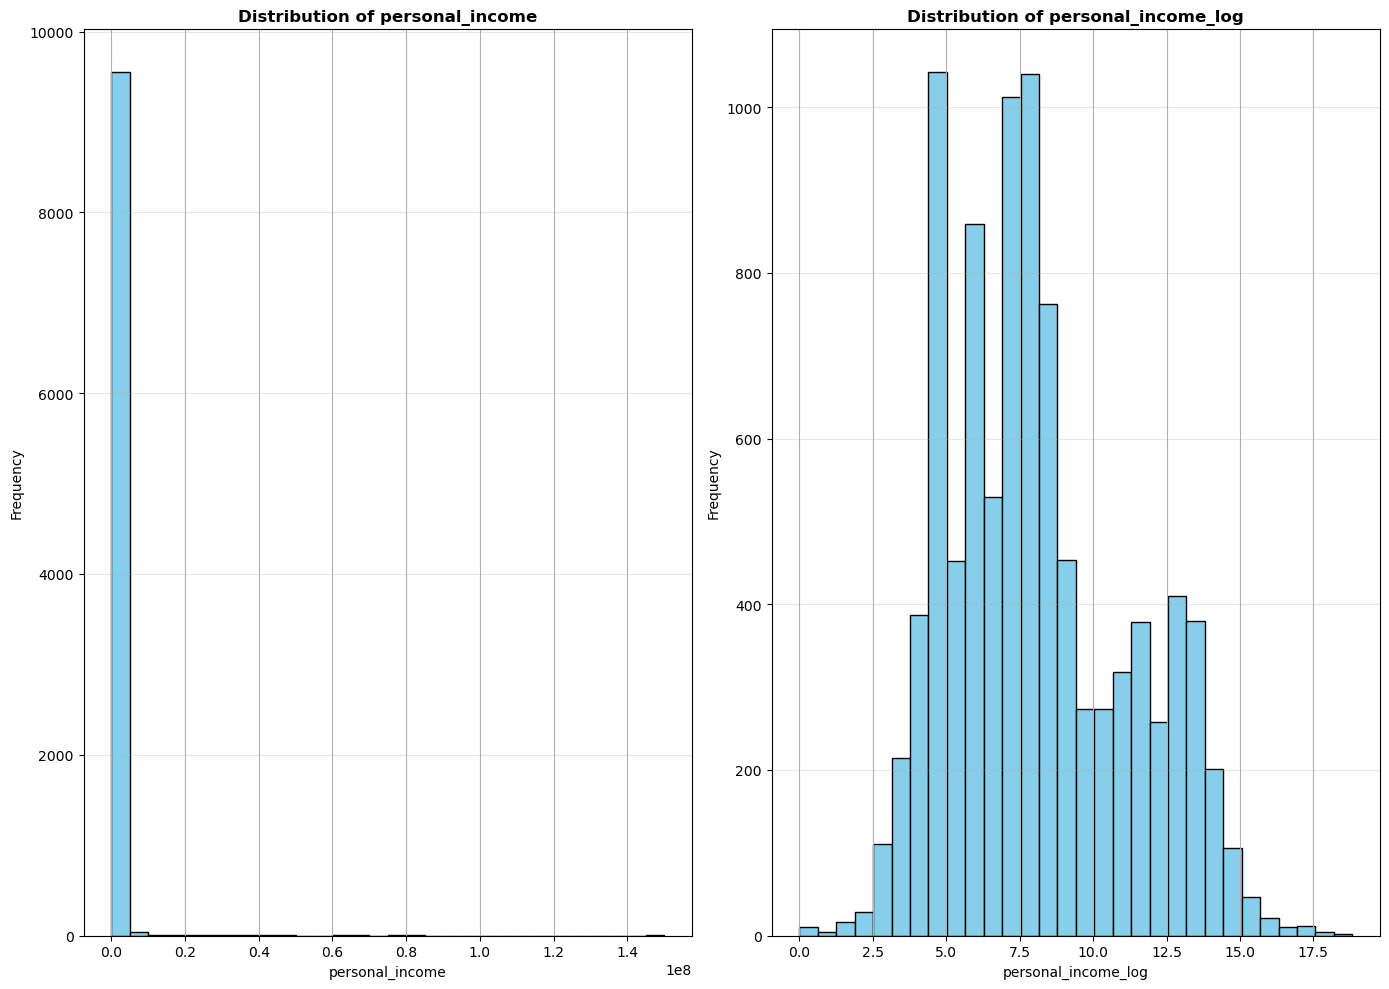

In [6]:
import matplotlib.pyplot as plt
key_numerical = ['personal_income','personal_income_log']
available_numerical = [col for col in key_numerical if col in train_df.columns]

if available_numerical:
    fig, axes = plt.subplots(1, 2, figsize=(14, 10))
    axes = axes.ravel()
    
    for idx, col in enumerate(available_numerical[:6]):
        train_df[col].hist(bins=30, ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')
        axes[idx].grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

### Series

In [24]:

s = pd.Series([10, 20, np.nan, 40], index=['a', 'b', 'c', 'd'])
#print(s)

# Basic operations
#print(s + 5)
#print(s.isna())
#print(s.fillna(0))

# DataFrame
df = pd.DataFrame({
    'Name': ['Alice', 'Bob', 'Charlie'],
    'Age': [25, 30, 35],
    'Salary': [50000, 60000, 70000]
})

# Selection
#print(df['Age'])
#print(df)
#print(df.loc[0:1, ['Name', 'Salary']]) #[row_names,column names] 


# Add column
df['Bonus'] = df['Salary'] * 0.10

# Conditional filtering
high_earners = df[df['Salary'] > 55000]
#print(high_earners)

# Handling missing values
#df['Age'] = df['Age'].fillna(df['Age'].mean())
high_earners

,Name,Age,Salary,Bonus
1,Bob,30,60000,6000.0
2,Charlie,35,70000,7000.0


In [22]:
print(df.iloc[1:3, 0:2]) #indexed search - position

      Name  Age
1      Bob   30
2  Charlie   35


### Aggregation, Grouping, and Pivot Tables

In [8]:
data = {
    'Department': ['IT', 'IT', 'HR', 'HR', 'Finance', 'Finance'],
    'Employee': ['A', 'B', 'C', 'D', 'E', 'F'],
    'Salary': [70000, 80000, 50000, 52000, 90000, 88000]
}

df = pd.DataFrame(data)

# Grouping
dept_avg_salary = df.groupby('Department')['Salary'].mean()
print(dept_avg_salary)

# Multiple aggregations
dept_stats = df.groupby('Department')['Salary'].agg(['mean', 'min', 'max'])
print(dept_stats)

# Custom aggregation
df.groupby('Department').agg(
    avg_salary=('Salary', 'mean'),
    employee_count=('Employee', 'count')
)


Department
Finance    89000.0
HR         51000.0
IT         75000.0
Name: Salary, dtype: float64
               mean    min    max
Department                       
Finance     89000.0  88000  90000
HR          51000.0  50000  52000
IT          75000.0  70000  80000


,avg_salary,employee_count
Department,,
Finance,89000.0,2
HR,51000.0,2
IT,75000.0,2


In [9]:
sales = pd.DataFrame({
    'Region': ['East', 'East', 'West', 'West'],
    'Product': ['A', 'B', 'A', 'B'],
    'Revenue': [1000, 1500, 2000, 1800]
})

pivot = pd.pivot_table(
    sales,
    values='Revenue',
    index='Region',
    columns='Product',
    aggfunc='sum'
)

print(pivot)


Product     A     B
Region             
East     1000  1500
West     2000  1800


### Merging, Joining, and Reshaping Datasets

In [10]:
customers = pd.DataFrame({
    'CustomerID': [1, 2, 3],
    'Name': ['Alice', 'Bob', 'Charlie']
})

orders = pd.DataFrame({
    'CustomerID': [1, 1, 2],
    'OrderAmount': [250, 450, 300]
})

# Inner join
merged_inner = pd.merge(customers, orders, on='CustomerID', how='inner')

# Left join
merged_left = pd.merge(customers, orders, on='CustomerID', how='left')

print(merged_left)


   CustomerID     Name  OrderAmount
0           1    Alice        250.0
1           1    Alice        450.0
2           2      Bob        300.0
3           3  Charlie          NaN


In [11]:
# Wide to long
wide = pd.DataFrame({
    'Year': [2022, 2023],
    'Sales_A': [100, 120],
    'Sales_B': [90, 110]
})

long = pd.melt(
    wide,
    id_vars='Year',
    value_vars=['Sales_A', 'Sales_B'],
    var_name='Product',
    value_name='Sales'
)

print(long)

# Stack & Unstack
stacked = pivot.stack()
print(stacked)

unstacked = stacked.unstack()
print(unstacked)


   Year  Product  Sales
0  2022  Sales_A    100
1  2023  Sales_A    120
2  2022  Sales_B     90
3  2023  Sales_B    110
Region  Product
East    A          1000
        B          1500
West    A          2000
        B          1800
dtype: int64
Product     A     B
Region             
East     1000  1500
West     2000  1800


#### Numerical Computations with NumPy
Why vectorization matters

Vectorized operations are:

Faster than Python loops

Optimized in C

Essential for large-scale data processing

In [12]:
# Create arrays
a = np.array([1, 2, 3, 4, 5])
b = np.array([10, 20, 30, 40, 50])

# Array properties
print(a.shape)
print(a.dtype)

# Vectorized operations (no loops)
print(a + b)
print(a * 2)
print(a ** 2)

# Boolean operations
print(a > 3)
print(a[a > 3])

# 2D arrays
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])

print(matrix)
print(matrix.T)   # Transpose


(5,)
int32
[11 22 33 44 55]
[ 2  4  6  8 10]
[ 1  4  9 16 25]
[False False False  True  True]
[4 5]
[[1 2 3]
 [4 5 6]]
[[1 4]
 [2 5]
 [3 6]]


In [13]:
data = np.array([12, 15, 18, 22, 30])

# Basic statistics
print(np.mean(data))
print(np.median(data))
print(np.std(data))
print(np.var(data))
print(np.min(data), np.max(data))

# Mathematical functions
print(np.sqrt(data))
print(np.log(data))
print(np.exp(data))

# Percentiles
print(np.percentile(data, 25))
print(np.percentile(data, 75))

# Axis-based operations
matrix = np.array([[1, 2, 3],
                   [4, 5, 6]])

print(np.sum(matrix, axis=0))  # column-wise
print(np.sum(matrix, axis=1))  # row-wise


19.4
18.0
6.248199740725323
39.04
12 30
[3.46410162 3.87298335 4.24264069 4.69041576 5.47722558]
[2.48490665 2.7080502  2.89037176 3.09104245 3.40119738]
[1.62754791e+05 3.26901737e+06 6.56599691e+07 3.58491285e+09
 1.06864746e+13]
15.0
22.0
[5 7 9]
[ 6 15]


### Homework 
##### Problem 1


Create a Pandas Series of 50 random integer values between 0 and 100.

Randomly insert at least 8 missing values (NaN) into the Series.

Perform the following operations:

Count the number of missing values.

Replace missing values with the median of the Series.

Normalize the Series using min–max scaling:
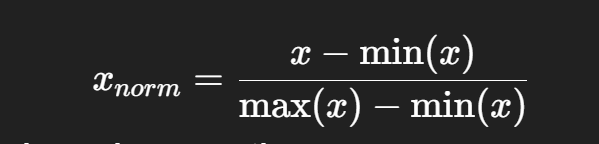


Identify all values that are above the 75th percentile.

Compute the mean and standard deviation of the normalized Series.

Constraints

❌ No NumPy array operations directly (use Pandas methods)

✅ Use vectorized Pandas operations only

##### Problem 2

Generate a NumPy array of 100,000 daily returns drawn from a normal distribution with:

Mean = 0.001

Standard deviation = 0.02

Compute the following using vectorized operations only:

Mean return

Volatility (standard deviation)

Minimum and maximum returns

Identify all days where the return is more than 2 standard deviations away from the mean.

Standardize the returns using Z-score normalization.

Report the percentage of extreme-return days.

Constraints

❌ No Python loops (for, while)

✅ Use NumPy vectorized operations only